In [1]:
# Task 1 : Data Preparation

In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv("heart_disease_csvFile.csv")

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    float64
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    float64
 4   chol      908 non-null    float64
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    float64
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    float64
dtypes: float64(6), object(7)
memory usage: 101.6+ KB
None


In [7]:
print(df.isnull().sum())

age          91
sex          91
cp           91
trestbps     91
chol         91
fbs          91
restecg      91
thalch       91
exang        91
oldpeak     153
slope        91
thal         91
num          91
dtype: int64


In [8]:
print(df.describe())

              age    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.891253    1.008811
std      9.158031   20.401608  112.097949   26.804929    1.093875    1.144436
min     29.000000    0.000000    0.000000   60.000000   -2.600000    0.000000
25%     47.750000  120.000000  176.750000  118.000000    0.000000    0.000000
50%     54.000000  130.000000  224.000000  138.000000    0.500000    1.000000
75%     60.000000  144.000000  270.000000  156.000000    1.500000    2.000000
max     77.000000  200.000000  603.000000  202.000000    6.200000    4.000000


In [9]:
# Task 2 : Exploratory Data Analysis(EDA)

In [14]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak','num']
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [15]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64


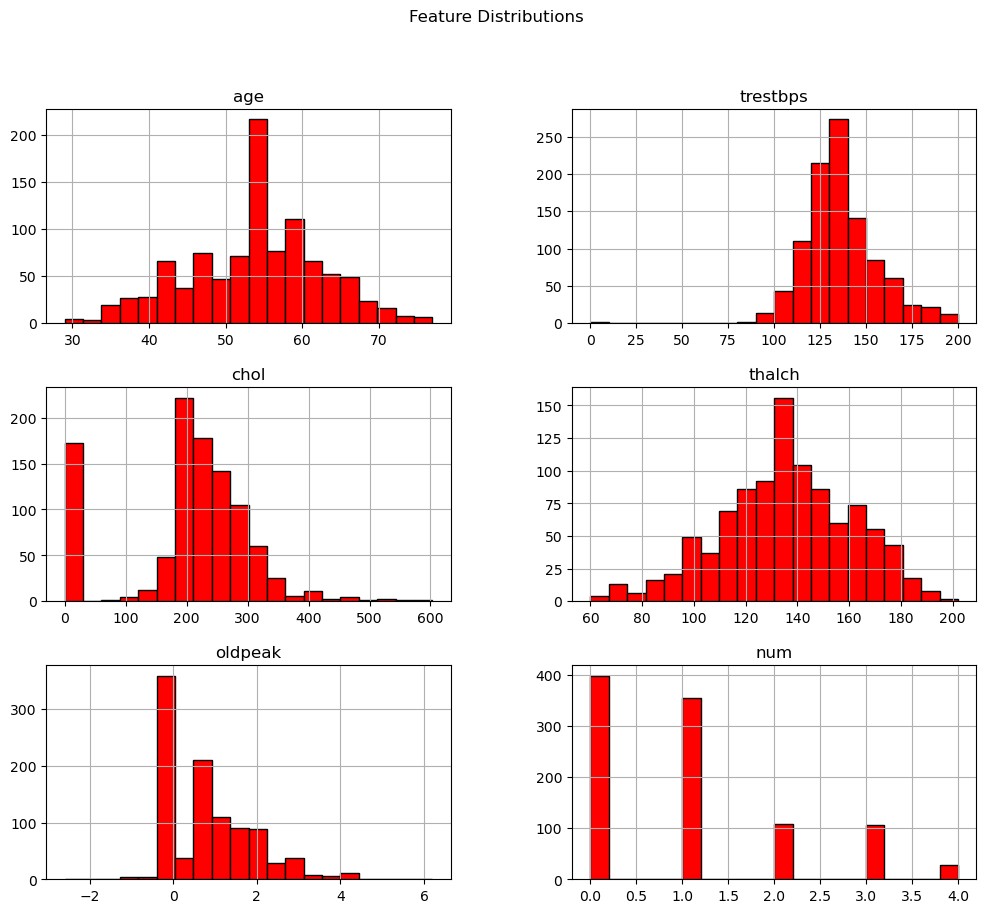

In [19]:
import matplotlib.pyplot as plt
df.hist(figsize=(12, 10), bins=20, color='red', edgecolor='black')
plt.suptitle("Feature Distributions")
plt.show()

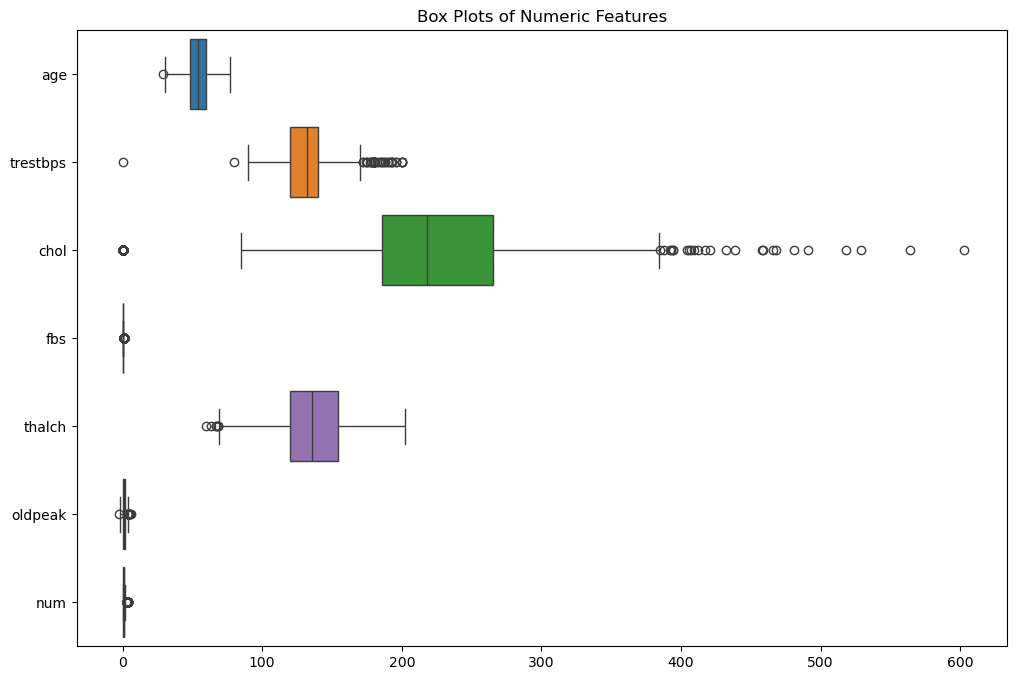

In [21]:
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, orient='h')
plt.title("Box Plots of Numeric Features")
plt.show()

In [24]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [26]:
# Task 3 : Feature Engineering

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

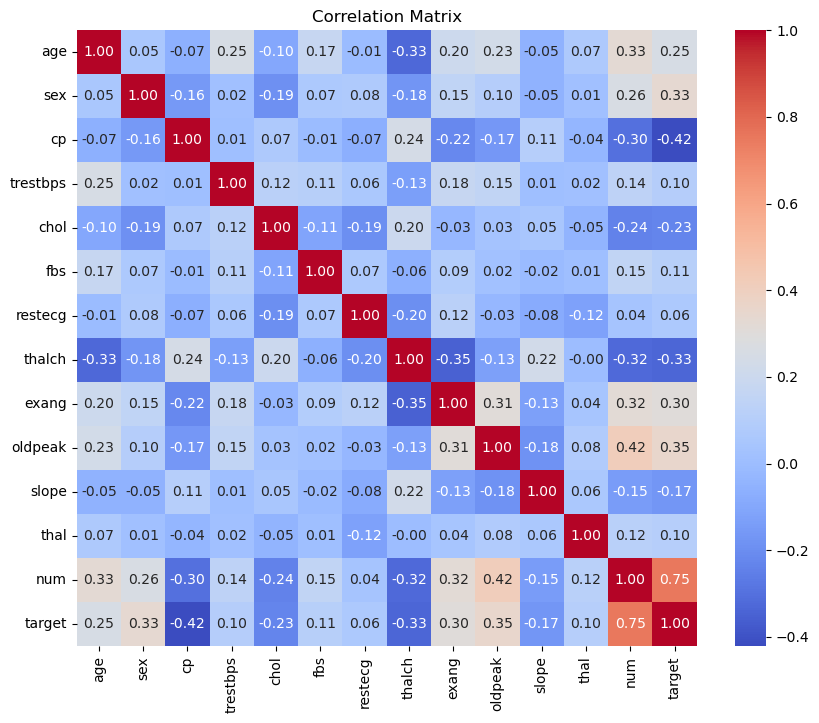

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [47]:
X = df.drop(['num','target'], axis=1)
y = df['target']  

In [48]:
# Task 4 : Decision Tree Classification

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 799, Testing samples: 200


In [51]:
dt_model = DecisionTreeClassifier(random_state=42,min_samples_split=20,min_samples_leaf=10,max_depth=5)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [52]:
y_pred = dt_model.predict(X_test)
y_pred_prob = dt_model.predict_proba(X_test)[:, 1]

In [53]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("Model Performance on Test Set:")
print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-Score : {f1:.2f}")
print(f"ROC-AUC  : {roc_auc:.2f}")

Model Performance on Test Set:
Accuracy : 0.76
Precision: 0.80
Recall   : 0.81
F1-Score : 0.80
ROC-AUC  : 0.83


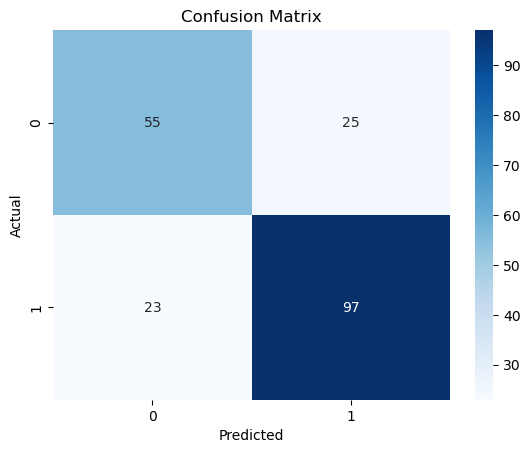

In [54]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [55]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': dt_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

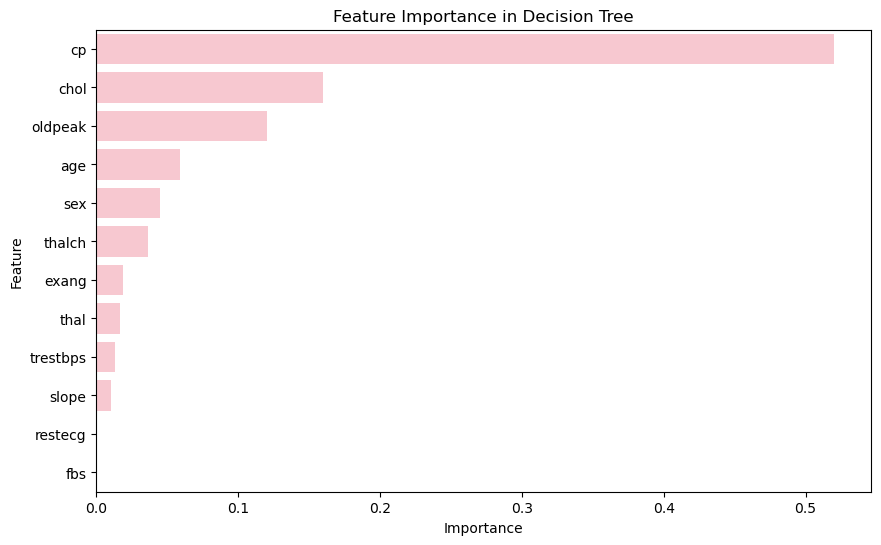

In [62]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance,color='pink')
plt.title("Feature Importance in Decision Tree")
plt.show()

In [63]:
# Task 5 : Hyperparameter Tuning

In [64]:
from sklearn.model_selection import GridSearchCV

In [65]:
param_grid = {
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,                
    scoring='f1',        
    n_jobs=-1            
)


In [66]:
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
best_dt = grid_search.best_estimator_

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [67]:
y_pred_2 = best_dt.predict(X_test)
y_pred_prob_2 = best_dt.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred_2)
precision = precision_score(y_test, y_pred_2)
recall = recall_score(y_test, y_pred_2)
f1 = f1_score(y_test, y_pred_2)
roc_auc = roc_auc_score(y_test, y_pred_prob_2)

print("Tuned Model Performance on Test Set:")
print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-Score : {f1:.2f}")
print(f"ROC-AUC  : {roc_auc:.2f}")

Tuned Model Performance on Test Set:
Accuracy : 0.75
Precision: 0.81
Recall   : 0.76
F1-Score : 0.78
ROC-AUC  : 0.81


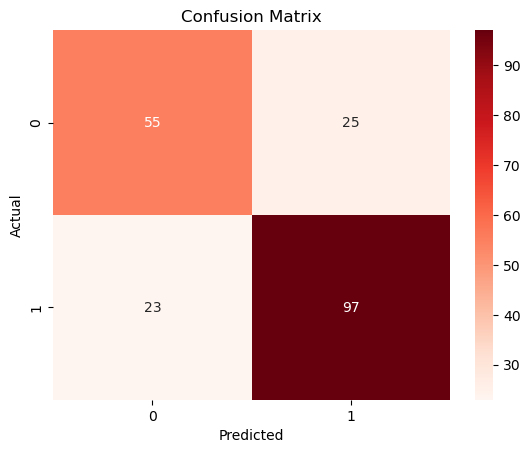

In [70]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

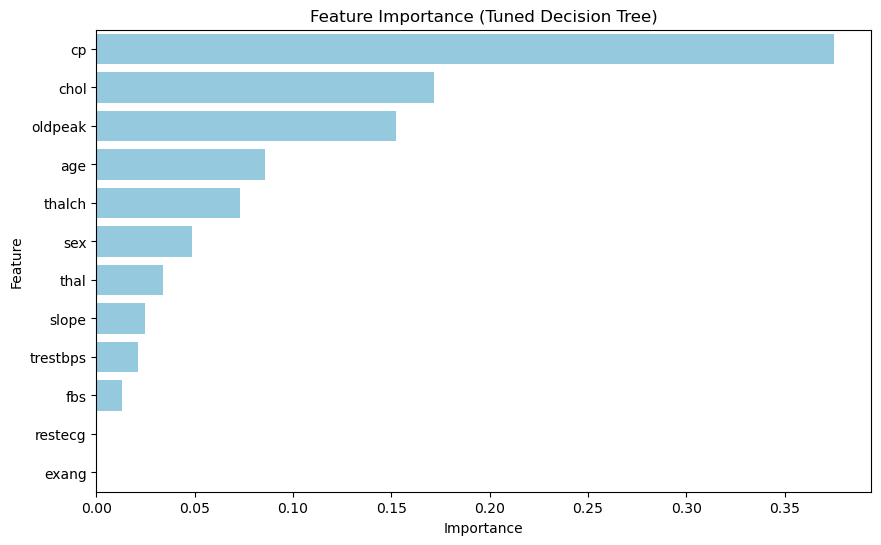

In [69]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, color='skyblue')
plt.title("Feature Importance (Tuned Decision Tree)")
plt.show()

In [71]:
# Task 6 : Model Evaluation and Analysis

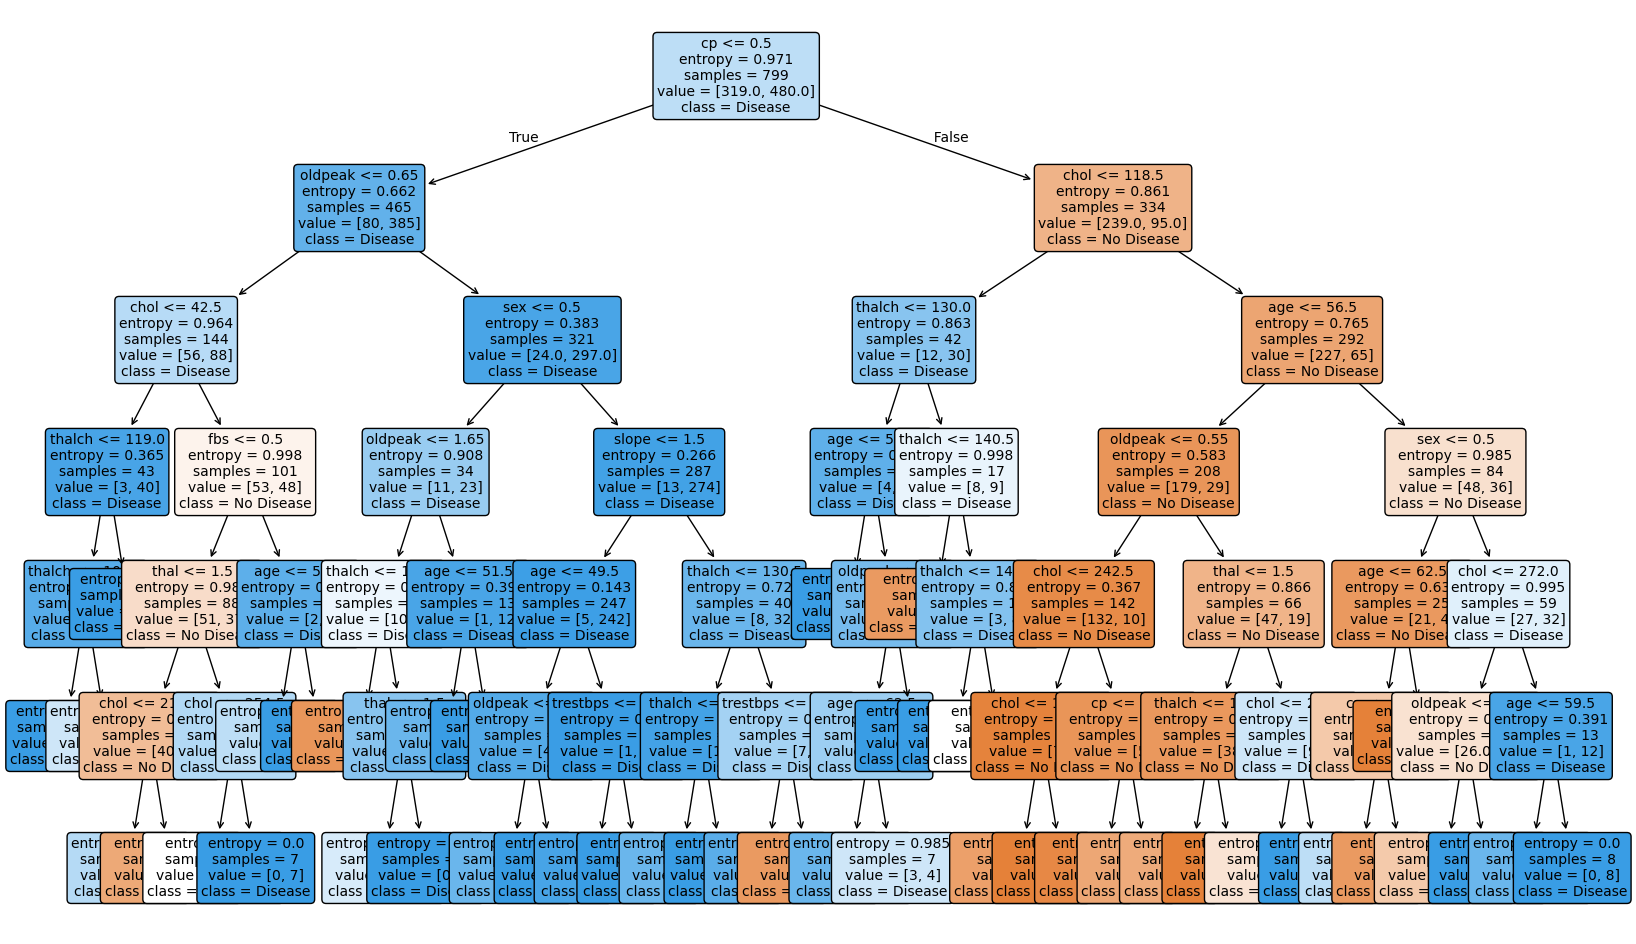

In [73]:
plt.figure(figsize=(20,12))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=['No Disease','Disease'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [74]:
# 1) What are some common hyperparameters of Decision Tree models, and how do they affect the model’s performance?
# --> a) max_depth - It denotes maximum number of levels in the tree. It limits how deep the tree can grow. 
#        Smaller depth indicates less overfitting, but too small will cause underfitting.
#     b) min_samples_split - It denotes minimum number of samples required to split a node.
#        Larger value will give fewer splits that makes simpler tree and prevents overfitting.
#     c) min_samples_leaf - It minimum number of samples required in each leaf node.
#         It ensures that leaves have enough data; smooths the model.
#     d) random_state - It controls randomness of splits. It ensures reproducibility of results.

In [ ]:
# What is the difference between Label Encoding and One-Hot Encoding?
# ---> A] Label Encoding :-
#       i) It assigns each category an integer value.
#       ii) It gives output as single numerical column.
#       iii) It is best suitable for ordinal data.
#       iv) It's disadvantage is algorithms may assume numerical relationship.
#       v) Eg- Color = [Red, Blue, Green] -> Red=0, Blue=1, Green=2
# ---> B] One-Hot Encoding :-
#       i) It creates a new binary column for each category.
#       ii) It gives output as multiple binary columns.
#       iii) It is best suitable for nominal data.
#       iv) It's disadvantages are it avoids false ordering and has more memory usage.
#       v) Eg- Color_Red=[1,0,0], Color_Blue=[0,1,0], Color_Green=[0,0,1]